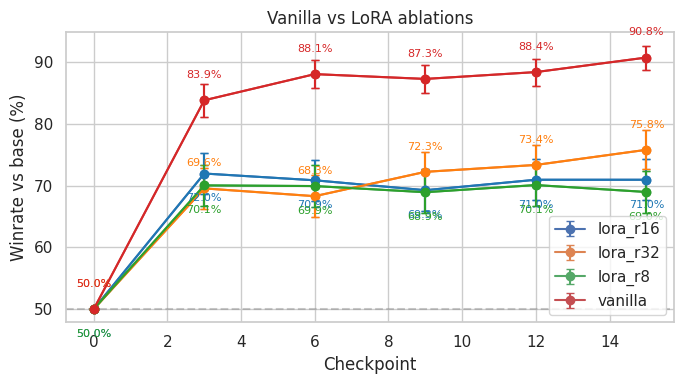

In [17]:
import json, re, seaborn as sns, matplotlib.pyplot as plt, pandas as pd
from pathlib import Path

rows = []
for p in Path("/tmp/sdpo-eval").rglob("tldr_*.json"):
    d = json.load(open(p))
    model_a = d["meta"]["model_a"]
    m = re.search(r"lora[_-](\d+)", model_a)
    tag = f"lora_r{m.group(1)}" if m else "vanilla"
    ckpt = int(re.search(r"ckpt(\d+)", d["meta"]["run_name"]).group(1))
    met = d["metrics"]
    rows.append({"tag": tag, "ckpt": ckpt, "winrate": met["winrate_a_ignoring_ties"], "se": met["winrate_a_ignoring_ties_bootstrap_se"]})

df = pd.DataFrame(rows).sort_values(["tag", "ckpt"])
df = pd.concat([df] + [pd.DataFrame([{"tag": t, "ckpt": 0, "winrate": 50, "se": 0}]) for t in df.tag.unique()]).sort_values(["tag", "ckpt"])

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 4))
for tag, g in df.groupby("tag"):
    ax.errorbar(g.ckpt, g.winrate, yerr=g.se, label=tag, marker="o", capsize=3)
ax.axhline(50, ls="--", c="gray", alpha=.4)
ax.set(xlabel="Checkpoint", ylabel="Winrate vs base (%)", title="Vanilla vs LoRA ablations")
ax.legend()

palette = dict(zip(sorted(df.tag.unique()), sns.color_palette("tab10", n_colors=df.tag.nunique())))

tag_colors = {}
for tag, g in df.groupby("tag"):
    c = palette[tag]
    line = ax.errorbar(g.ckpt, g.winrate, yerr=g.se, label=tag, marker="o", capsize=3, color=c)
    tag_colors[tag] = c

for _, r in df.iterrows():
    c = tag_colors[r.tag]
    if r.tag in ("vanilla", "lora_r32"):
        ax.annotate(f"{r.winrate:.1f}%", (r.ckpt, r.winrate), textcoords="offset points", xytext=(0, 16), ha="center", fontsize=8, color=c)
    elif r.tag in ("lora_r8", "lora_r16"):
        ax.annotate(f"{r.winrate:.1f}%", (r.ckpt, r.winrate), textcoords="offset points", xytext=(0, -20), ha="center", fontsize=8, color=c)
plt.tight_layout()